In [188]:
'''!pip install -q xgboost'''

'!pip install -q xgboost'

In [189]:
import pandas as pd
import xgboost
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import max_error, explained_variance_score
from sklearn.metrics import accuracy_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [190]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

numpy     : 2.3.5
xgboost   : 3.1.2
pandas    : 2.3.3
seaborn   : 0.13.2
matplotlib: 3.10.0
sklearn   : 1.6.1



In [191]:
df = pd.read_csv("C:/Users/03828092/Desktop/mt/p/dataset.csv")

In [192]:
df.head(3)

,ID_Emprestimo,Genero,Casado,Dependentes,Educacao,Empreendedor,SalarioAnualAplicantePrincipal,SalarioAnualCoAplicante,Score_Risco,TempoEmprestimo,Historico_Credito,LocalResidencia,StatusEmprestimo
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID_Emprestimo                   600 non-null    object 
 1   Genero                          587 non-null    object 
 2   Casado                          597 non-null    object 
 3   Dependentes                     585 non-null    object 
 4   Educacao                        600 non-null    object 
 5   Empreendedor                    570 non-null    object 
 6   SalarioAnualAplicantePrincipal  600 non-null    int64  
 7   SalarioAnualCoAplicante         600 non-null    float64
 8   Score_Risco                     579 non-null    float64
 9   TempoEmprestimo                 586 non-null    float64
 10  Historico_Credito               551 non-null    float64
 11  LocalResidencia                 600 non-null    object 
 12  StatusEmprestimo                600 

# Análise Exploratória, Limpeza e Engenharia de Atributos

<Axes: >

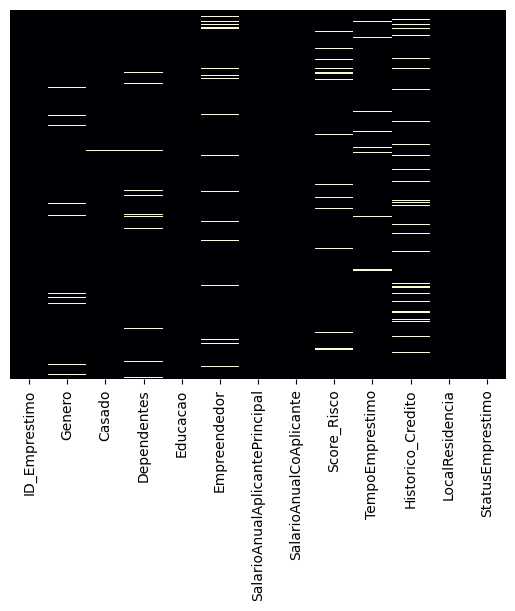

In [194]:
sns.heatmap(df.isnull(), yticklabels = False, cbar= False, cmap="magma")

In [195]:
percentual_ausentes = df.isnull().mean() * 100
print(percentual_ausentes)

ID_Emprestimo                     0.000000
Genero                            2.166667
Casado                            0.500000
Dependentes                       2.500000
Educacao                          0.000000
Empreendedor                      5.000000
SalarioAnualAplicantePrincipal    0.000000
SalarioAnualCoAplicante           0.000000
Score_Risco                       3.500000
TempoEmprestimo                   2.333333
Historico_Credito                 8.166667
LocalResidencia                   0.000000
StatusEmprestimo                  0.000000
dtype: float64


In [196]:
df['Genero'].value_counts()

Genero
Male      473
Female    114
Name: count, dtype: int64

In [197]:
genero = pd.get_dummies(df['Genero'], drop_first = True)

In [198]:
df.drop(['Genero', 'ID_Emprestimo'], axis=1, inplace=True)

In [199]:
df = pd.concat([df, genero], axis = 1)

In [200]:
casado = pd.get_dummies(df['Casado'], drop_first = True)

In [201]:
df = pd.concat([df, casado], axis = 1)

In [202]:
df.head()

,Casado,Dependentes,Educacao,Empreendedor,SalarioAnualAplicantePrincipal,SalarioAnualCoAplicante,Score_Risco,TempoEmprestimo,Historico_Credito,LocalResidencia,StatusEmprestimo,Male,Yes
0,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,True,False
1,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,True,True
2,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,True,True
3,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,True,True
4,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,True,False


In [203]:
df = df.rename(columns = {'Yes': 'Casado'})

In [204]:
graduado = pd.get_dummies(df['Educacao'], drop_first=True)

In [205]:
empreendedor = pd.get_dummies(df['Empreendedor'], drop_first=True)

In [206]:
df = pd.concat([df, graduado, empreendedor], axis = 1)

In [207]:
df.drop(['Casado', 'Empreendedor', 'Educacao'], axis=1, inplace=True)

In [208]:
df.head(3)

,Dependentes,SalarioAnualAplicantePrincipal,SalarioAnualCoAplicante,Score_Risco,TempoEmprestimo,Historico_Credito,LocalResidencia,StatusEmprestimo,Male,Not Graduate,Yes
0,0,5849,0.0,NaN,360.0,1.0,Urban,Y,True,False,False
1,1,4583,1508.0,128.0,360.0,1.0,Rural,N,True,False,False
2,0,3000,0.0,66.0,360.0,1.0,Urban,Y,True,False,True


In [209]:
df = df.rename(columns = {'Yes': 'Empreendedor', 'Not Graduate': 'Sem_Graduacao', 'Male': 'Genero_Masculino'})

In [210]:
df.head()

,Dependentes,SalarioAnualAplicantePrincipal,SalarioAnualCoAplicante,Score_Risco,TempoEmprestimo,Historico_Credito,LocalResidencia,StatusEmprestimo,Genero_Masculino,Sem_Graduacao,Empreendedor
0,0,5849,0.0,NaN,360.0,1.0,Urban,Y,True,False,False
1,1,4583,1508.0,128.0,360.0,1.0,Rural,N,True,False,False
2,0,3000,0.0,66.0,360.0,1.0,Urban,Y,True,False,True
3,0,2583,2358.0,120.0,360.0,1.0,Urban,Y,True,True,False
4,0,6000,0.0,141.0,360.0,1.0,Urban,Y,True,False,False


<Axes: >

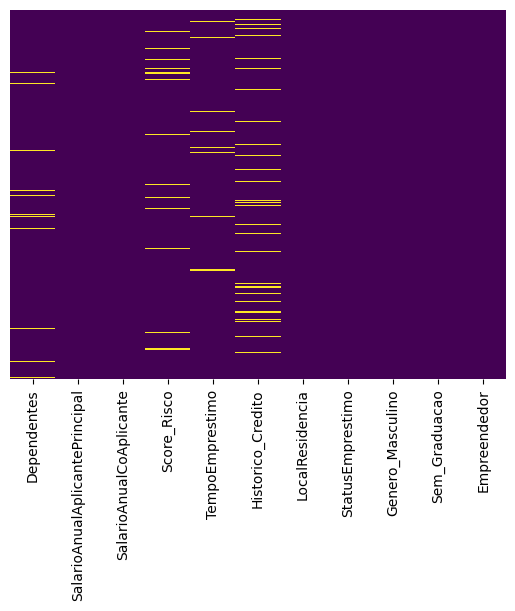

In [211]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap='viridis')

In [212]:
df.drop(['Historico_Credito'], axis=1, inplace=True)

In [213]:
df = df.dropna(subset = ['TempoEmprestimo', 'Dependentes', 'Score_Risco'])

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 553 entries, 1 to 599
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Dependentes                     553 non-null    object 
 1   SalarioAnualAplicantePrincipal  553 non-null    int64  
 2   SalarioAnualCoAplicante         553 non-null    float64
 3   Score_Risco                     553 non-null    float64
 4   TempoEmprestimo                 553 non-null    float64
 5   LocalResidencia                 553 non-null    object 
 6   StatusEmprestimo                553 non-null    object 
 7   Genero_Masculino                553 non-null    bool   
 8   Sem_Graduacao                   553 non-null    bool   
 9   Empreendedor                    553 non-null    bool   
dtypes: bool(3), float64(3), int64(1), object(3)
memory usage: 36.2+ KB


<Axes: xlabel='Dependentes', ylabel='count'>

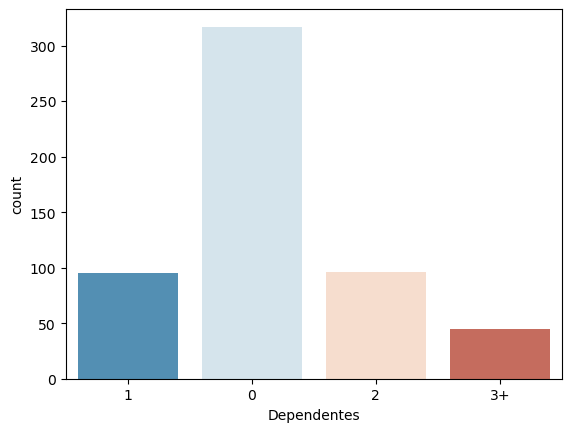

In [215]:
sns.countplot(x = 'Dependentes', data = df, palette = 'RdBu_r')

In [216]:
df = df.replace(to_replace = '3+', value = 3)

<Axes: xlabel='Dependentes', ylabel='count'>

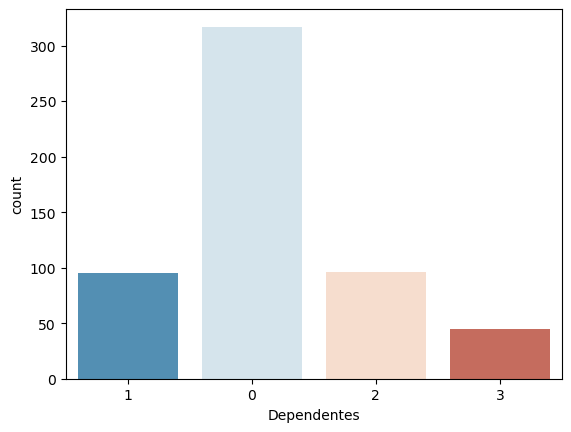

In [217]:
sns.countplot(x = 'Dependentes', data = df, palette = 'RdBu_r')


<Axes: >

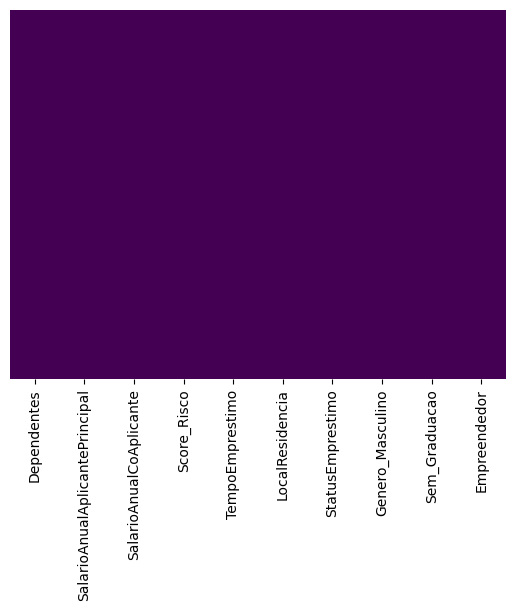

In [218]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap='viridis')


In [219]:
status_emprestimo = pd.get_dummies(df['StatusEmprestimo'], drop_first=True)
df.drop(['StatusEmprestimo'], axis=1, inplace=True)
df = pd.concat([df, status_emprestimo], axis=1)

In [220]:
df.sample(3)

,Dependentes,SalarioAnualAplicantePrincipal,SalarioAnualCoAplicante,Score_Risco,TempoEmprestimo,LocalResidencia,Genero_Masculino,Sem_Graduacao,Empreendedor,Y
64,0,4166,0.0,116.0,360.0,Semiurban,False,False,False,False
480,0,4350,0.0,154.0,360.0,Rural,False,True,False,True
442,3,4707,1993.0,148.0,360.0,Semiurban,True,True,False,True


In [221]:
df = df.rename(columns = {'Y': 'recebe_Emprestimo'})

In [222]:
localresidencia = pd.get_dummies(df['LocalResidencia'], drop_first = True)
df.drop(['LocalResidencia'], axis=1, inplace=True)
df = pd.concat([df, localresidencia], axis=1)

In [223]:
df.sample(3)

,Dependentes,SalarioAnualAplicantePrincipal,SalarioAnualCoAplicante,Score_Risco,TempoEmprestimo,Genero_Masculino,Sem_Graduacao,Empreendedor,recebe_Emprestimo,Semiurban,Urban
506,0,20833,6667.0,480.0,360.0,True,False,False,True,False,True
93,0,4133,0.0,122.0,360.0,True,False,False,True,True,False
200,1,2600,2500.0,90.0,360.0,True,True,False,True,True,False


In [224]:
df = df.rename(columns = {'Urban': 'AreaUrbana', 'Semiurban': 'AreaSemiurbana'})

In [225]:
df.sample(10)

,Dependentes,SalarioAnualAplicantePrincipal,SalarioAnualCoAplicante,Score_Risco,TempoEmprestimo,Genero_Masculino,Sem_Graduacao,Empreendedor,recebe_Emprestimo,AreaSemiurbana,AreaUrbana
190,0,4885,0.0,48.0,360.0,True,True,False,True,False,False
177,3,5516,11300.0,495.0,360.0,True,False,False,False,True,False
302,0,5000,0.0,132.0,360.0,False,False,False,True,False,False
373,1,3062,1987.0,111.0,180.0,True,False,False,False,False,True
474,2,5532,4648.0,162.0,360.0,True,False,False,True,False,False
352,3,2666,2083.0,95.0,48.0,True,False,False,True,False,False
445,1,3466,1210.0,130.0,360.0,True,False,True,True,False,False
306,0,3762,1666.0,135.0,360.0,False,False,False,True,False,False
254,0,16250,0.0,192.0,360.0,True,False,True,False,False,True
270,0,3237,0.0,30.0,360.0,False,False,False,True,False,True


In [226]:
df.columns

Index(['Dependentes', 'SalarioAnualAplicantePrincipal',
       'SalarioAnualCoAplicante', 'Score_Risco', 'TempoEmprestimo',
       'Genero_Masculino', 'Sem_Graduacao', 'Empreendedor',
       'recebe_Emprestimo', 'AreaSemiurbana', 'AreaUrbana'],
      dtype='object')

In [227]:
X = df.drop(columns = ['recebe_Emprestimo'])
y = df['recebe_Emprestimo']

In [228]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.30)

In [229]:
X_treino

,Dependentes,SalarioAnualAplicantePrincipal,SalarioAnualCoAplicante,Score_Risco,TempoEmprestimo,Genero_Masculino,Sem_Graduacao,Empreendedor,AreaSemiurbana,AreaUrbana
87,0,2500,2118.0,104.0,360.0,True,False,False,True,False
15,0,4950,0.0,125.0,360.0,True,False,False,False,True
292,2,3153,1560.0,134.0,360.0,True,False,False,False,True
296,1,6875,0.0,200.0,360.0,False,False,False,True,False
491,1,5333,1131.0,186.0,360.0,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...
591,2,6000,0.0,205.0,240.0,True,False,True,True,False
357,1,3875,0.0,67.0,360.0,True,False,False,False,True
594,0,16120,0.0,260.0,360.0,True,False,True,False,True
209,0,3418,0.0,127.0,360.0,True,False,False,True,False


In [230]:
scaler_cls = StandardScaler()

In [231]:
scaler_cls.fit(X_treino)

StandardScaler()

In [232]:
X_treino_scaled = scaler_cls.transform(X_treino)
X_teste_scaled = scaler_cls.transform(X_teste)

# Algoritmo KNN (K vizinhos mais próximos)

In [233]:
modelo_cls = KNeighborsClassifier(n_neighbors = 3)

In [234]:
modelo_cls.fit(X_treino_scaled, y_treino)

KNeighborsClassifier(n_neighbors=3)

In [235]:
pred = modelo_cls.predict(X_teste_scaled)

In [236]:
print(confusion_matrix(y_teste, pred))

[[11 41]
 [24 90]]


In [237]:
print(classification_report(y_teste, pred))

              precision    recall  f1-score   support

       False       0.31      0.21      0.25        52
        True       0.69      0.79      0.73       114

    accuracy                           0.61       166
   macro avg       0.50      0.50      0.49       166
weighted avg       0.57      0.61      0.58       166



In [238]:
error_rate = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_treino_scaled, y_treino)
    pred_i = knn.predict(X_teste_scaled)
    error_rate.append(np.mean(pred_i != y_teste))

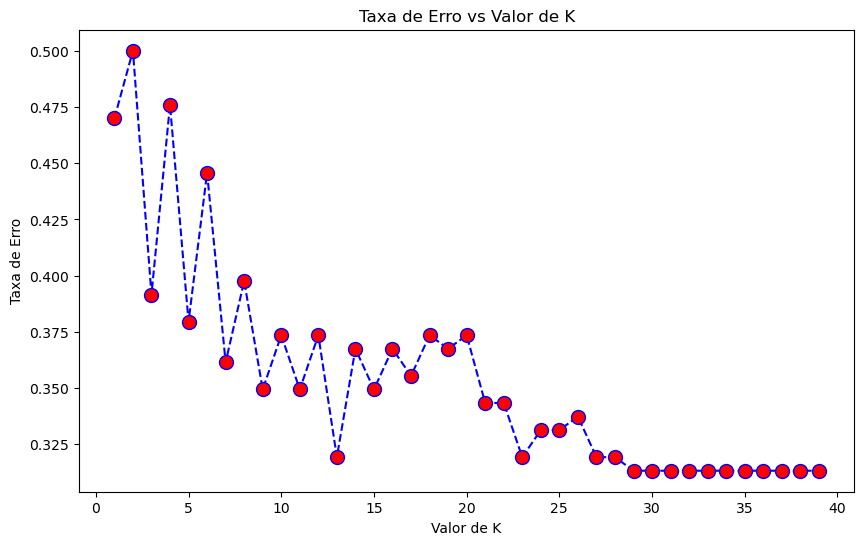

In [239]:
plt.figure(figsize = (10,6))
plt.plot(range(1,40),
         error_rate,
         color = 'blue',
         linestyle = 'dashed',
         marker = 'o',
         markerfacecolor = 'red',
         markersize = 10)
plt.title('Taxa de Erro vs Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Taxa de Erro')
plt.show() 

In [240]:
knn = KNeighborsClassifier(n_neighbors = 15)

In [241]:
knn.fit(X_treino_scaled, y_treino)

KNeighborsClassifier(n_neighbors=15)

In [242]:
pred = knn.predict(X_teste_scaled)

In [243]:
print(confusion_matrix(y_teste, pred))

[[  2  50]
 [  8 106]]


In [244]:
print(classification_report(y_teste, pred))

              precision    recall  f1-score   support

       False       0.20      0.04      0.06        52
        True       0.68      0.93      0.79       114

    accuracy                           0.65       166
   macro avg       0.44      0.48      0.42       166
weighted avg       0.53      0.65      0.56       166



In [245]:
print(accuracy_score(y_teste, pred))

0.6506024096385542


In [246]:
novo_cliente_cls = np.array([1.4554, 1229.0, 158.0, 360.0, True, True, True, False, False, True]).reshape(1, -1)
novo_cliente_cls = scaler_cls.transform(novo_cliente_cls)

In [247]:
pred_novo_cliente_cls = knn.predict(novo_cliente_cls)

if pred_novo_cliente_cls[0] == True:
    print('Este cliente pode receber empréstimo!')
else:
    print('Não recomendo conceber empréstimo a este cliente!')

Este cliente pode receber empréstimo!


# Explorando Algoritmos

In [248]:
X = df.drop(columns = ['Score_Risco'])
y = df['Score_Risco']

In [249]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.30)

In [250]:
scaler_reg = StandardScaler()

In [253]:
scaler_reg.fit(X_treino)

StandardScaler()

<h1> Regressão Linear 

In [256]:
modelo_v1 = LinearRegression()

In [257]:
modelo_v1.fit(X_treino_scaled, y_treino) 

LinearRegression()

In [260]:
pred1_treino = modelo_v1.predict(X_treino_scaled)

In [262]:
print(f'Erro do Modelo: {max_error(y_treino, pred1_treino)}')
print(f'Explained variance Score: {explained_variance_score(y_treino, pred1_treino)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_treino, pred1_treino)}')

Erro do Modelo: 528.0371077015267
Explained variance Score: 0.034509543401111564
Mean Absolute Error: 52.13505616721756


In [263]:
pred1_teste = modelo_v1.predict(X_teste_scaled)

In [265]:
print(f'Erro do Modelo: {max_error(y_teste, pred1_teste)}')
print(f'Explained variance Score: {explained_variance_score(y_teste, pred1_teste)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_teste, pred1_teste)}')

Erro do Modelo: 450.425630590654
Explained variance Score: 0.002207892934915079
Mean Absolute Error: 59.23999006272251


# Regressão com Modelo bayesiano

In [267]:
modelo_v2 = BayesianRidge()

In [268]:
modelo_v2.fit(X_treino_scaled, y_treino)

BayesianRidge()

In [269]:
pred2_treino = modelo_v2.predict(X_treino_scaled)

In [270]:
print(f'Erro do Modelo: {max_error(y_treino, pred2_treino)}')
print(f'Explained Variance Score: {explained_variance_score(y_treino, pred2_treino)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_treino, pred2_treino)}')

Erro do Modelo: 556.8059051262243
Explained Variance Score: 1.2769965546000073e-05
Mean Absolute Error: 52.18349932687418


In [271]:
pred2_teste = modelo_v2.predict(X_teste_scaled)

In [272]:
print(f'Erro do Modelo: {max_error(y_teste, pred2_teste)}')
print(f'Explained Variance Score: {explained_variance_score(y_teste, pred2_teste)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_teste, pred2_teste)}')

Erro do Modelo: 456.81086739869147
Explained Variance Score: 3.7215088852793343e-06
Mean Absolute Error: 60.77689388383215


# Algoritmo de Random Forest

In [273]:
modelo_v3 =  RandomForestRegressor(max_depth = 2, random_state = 0)

In [274]:
modelo_v3.fit(X_treino_scaled, y_treino)

RandomForestRegressor(max_depth=2, random_state=0)

In [275]:
pred3_treino = modelo_v3.predict(X_treino_scaled)

In [276]:
print(f'Erro do Modelo: {max_error(y_treino, pred3_treino)}')
print(f'Explained Variance Score: {explained_variance_score(y_treino, pred3_treino)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_treino, pred3_treino)}')

Erro do Modelo: 509.04943473993785
Explained Variance Score: 0.10764722789355474
Mean Absolute Error: 50.84497573333137


In [277]:
pred3_teste = modelo_v3.predict(X_teste_scaled)

In [279]:
print(f'Erro do Modelo: {max_error(y_teste, pred3_teste)}')
print(f'Explained Variance Score: {explained_variance_score(y_teste, pred3_teste)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_teste, pred3_teste)}')

Erro do Modelo: 453.24192529471173
Explained Variance Score: -0.002642235602603016
Mean Absolute Error: 60.73843460886991


# Algoritmo XGBoost

In [280]:
modelo_v4 = XGBRegressor()

In [281]:
modelo_v4.fit(X_treino_scaled, y_treino)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [282]:
pred4_treino = modelo_v4.predict(X_treino_scaled)

In [284]:
print(f'Erro do Modelo: {max_error(y_treino, pred4_treino)}')
print(f'Explained Variance Score: {explained_variance_score(y_treino, pred4_treino)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_treino, pred4_treino)}')

Erro do Modelo: 9.631240844726562
Explained Variance Score: 0.9991354273586087
Mean Absolute Error: 1.607192813272008


In [286]:
pred4_teste = modelo_v4.predict(X_teste_scaled)

In [287]:
print(f'Erro do Modelo: {max_error(y_teste, pred4_teste)}')
print(f'Explained Variance Score: {explained_variance_score(y_teste, pred4_teste)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_teste, pred4_teste)}')

Erro do Modelo: 434.05711364746094
Explained Variance Score: -0.2794270106271459
Mean Absolute Error: 71.71514354843691


# Corrigindo o Overfitting

In [289]:
importancias = modelo_v3.feature_importances_

In [290]:
importancias = pd.DataFrame({
    'Variavel': X_treino.columns,
    'Importância': importancias})

In [291]:
importancias = importancias.sort_values(by = 'Importância', ascending = False)

In [292]:
importancias

,Variavel,Importância
3,TempoEmprestimo,0.417602
4,Genero_Masculino,0.198703
1,SalarioAnualAplicantePrincipal,0.152286
2,SalarioAnualCoAplicante,0.086686
8,AreaSemiurbana,0.048972
0,Dependentes,0.045712
6,Empreendedor,0.031519
5,Sem_Graduacao,0.010702
9,AreaUrbana,0.004852
7,recebe_Emprestimo,0.002966


In [293]:
top3_variaveis = importancias['Variavel'].head(3).values

In [294]:
X_treino_relevantes = X_treino[top3_variaveis]

In [298]:
X_teste_relevantes = X_teste[top3_variaveis]

In [295]:
scaler_reg = StandardScaler()

In [296]:
scaler_reg.fit(X_treino_relevantes)

StandardScaler()

In [299]:
X_treino_scaled = scaler_reg.transform(X_treino_relevantes)
X_teste_scaled = scaler_reg.transform(X_teste_relevantes)

In [300]:
modelo_v3 = RandomForestRegressor(n_estimators = 200, max_depth = 5)
modelo_v3.fit(X_treino_scaled, y_treino)

RandomForestRegressor(max_depth=5, n_estimators=200)

In [301]:
pred3_treino = modelo_v3.predict(X_treino_scaled)

In [302]:
print(f'Erro do Modelo: {max_error(y_treino, pred3_treino)}')
print(f'Explained Variance Score: {explained_variance_score(y_treino, pred3_treino)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_treino, pred3_treino)}')

Erro do Modelo: 202.25101690955694
Explained Variance Score: 0.6791847076232305
Mean Absolute Error: 33.97831650265078


In [303]:
pred3_teste = modelo_v3.predict(X_teste_scaled)

In [305]:
print(f'Erro do Modelo: {max_error(y_teste, pred3_teste)}')
print(f'Explained Variance Score: {explained_variance_score(y_teste, pred3_teste)}')
print(f'Mean Absolute Error: {mean_absolute_error(y_teste, pred3_teste)}')

Erro do Modelo: 329.82080694475206
Explained Variance Score: 0.3897249106796016
Mean Absolute Error: 49.54120047054552
